# 05 · How big is the effect? Theory benchmark, changing exposure, and monthly dynamics

1. **Benchmark test.** Does the trade-share formula d ln NTT ≈ (s_x − s_m)·d ln P_oil explain the data? Regress Δln NTT on the benchmark-weighted oil change; theory predicts a coefficient of **1**.
2. **Rolling elasticity.** Has India's sensitivity to oil fallen as refined-product exports grew (L08 RCA, L16 scale economies)?
3. **Monthly local projections (Jordà 2005).** How fast does the merchandise ToT react to an oil price change? Includes the 2026 Hormuz crisis.

In [1]:
# Shared setup: the helper modules live in ../src (chart style, econometrics helpers, data loader)
import sys; sys.path.append("../src")
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from style import *
import econ
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
m, a, c = econ.load()

## 1. Benchmark test (merchandise NTT, FY1995-96 to FY2024-25)

In [2]:
b = a.loc[1994:2024, ["ntt_rbi_chained", "real_oil_avg", "real_nonenergy", "benchmark_elasticity"]].copy()
b["dntt"] = np.log(b.ntt_rbi_chained).diff(); b["doil"] = np.log(b.real_oil_avg).diff(); b["dnon"] = np.log(b.real_nonenergy).diff()
b["bench_x_doil"] = b.benchmark_elasticity.shift(1) * b.doil      # last year's shares x this year's oil change
r_b = smf.ols("dntt ~ bench_x_doil + dnon", data=b.dropna()).fit(cov_type="HAC", cov_kwds={"maxlags": 1})
r_e = smf.ols("dntt ~ doil + dnon", data=b.dropna()).fit(cov_type="HAC", cov_kwds={"maxlags": 1})
t1 = r_b.t_test("bench_x_doil = 1")
tab = pd.DataFrame({
    "Benchmark-weighted oil change (theory predicts 1)": [r_b.params["bench_x_doil"], r_b.bse["bench_x_doil"], r_b.pvalues["bench_x_doil"], float(t1.pvalue), r_b.rsquared, int(r_b.nobs)],
    "Plain oil elasticity": [r_e.params["doil"], r_e.bse["doil"], r_e.pvalues["doil"], np.nan, r_e.rsquared, int(r_e.nobs)],
}, index=["coefficient", "HAC s.e.", "p (coef = 0)", "p (coef = 1)", "R²", "N"]).T
save_table(tab, "t07_benchmark_test")
print(f"Average benchmark s_x - s_m over the sample: {b.benchmark_elasticity.mean():.3f}")
tab

Average benchmark s_x - s_m over the sample: -0.159


,coefficient,HAC s.e.,p (coef = 0),p (coef = 1),R²,N
Benchmark-weighted oil change (theory predicts 1),1.696,0.384,0.000,0.070,0.349,30.000
Plain oil elasticity,-0.302,0.061,0.000,NaN,0.409,30.000


**Reading.**
- The coefficient is positive and significant, and we cannot reject that it equals 1 at the 5% level.
- So the simple trade-share accounting from the definition of ToT (L21) gets the **direction and the order of magnitude** right.
- The point estimate above 1 says the actual effect is somewhat larger than the direct oil channel. Oil also raises prices of other things India imports: fertiliser, petrochemicals, plastics, freight (CIF valuation, L14).

## 2. Is India becoming less exposed? Rolling 20-year elasticity

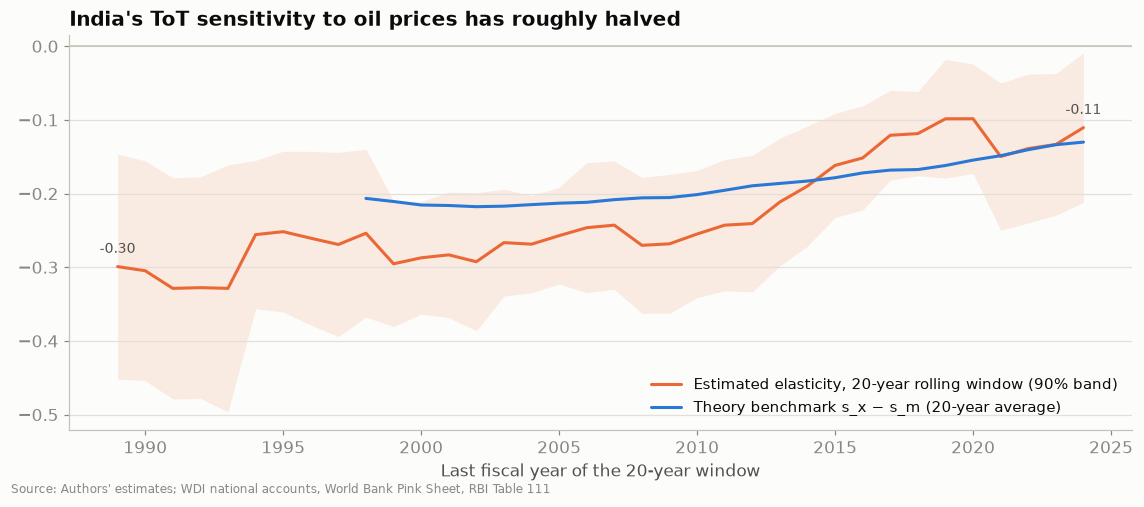

In [3]:
r = np.log(a.loc[1970:2024, ["tot_gs_na", "real_oil_avg", "real_nonenergy"]]).diff().dropna()
r.columns = ["dy", "dx", "dz"]
roll = []
for end in range(1989, 2025):
    w = r.loc[end - 19:end]
    f = smf.ols("dy ~ dx + dz", data=w).fit(cov_type="HC1")
    roll.append({"window end FY": end, "elasticity": f.params["dx"], "se": f.bse["dx"]})
roll = pd.DataFrame(roll).set_index("window end FY")
save_table(roll, "t08b_rolling_elasticity")
fig, ax = plt.subplots(figsize=(10.5, 4.6))
ax.fill_between(roll.index, roll.elasticity - 1.645 * roll.se, roll.elasticity + 1.645 * roll.se, color=ORANGE, alpha=0.12, lw=0)
ax.plot(roll.index, roll.elasticity, color=ORANGE, label="Estimated elasticity, 20-year rolling window (90% band)")
bm = a.loc[1989:2024, "benchmark_elasticity"].rolling(20, min_periods=10).mean()
ax.plot(bm.index, bm, color=BLUE, label="Theory benchmark s_x − s_m (20-year average)")
ax.axhline(0, color=AXIS, lw=1)
ax.set_title("India's ToT sensitivity to oil prices has roughly halved")
ax.set_xlabel("Last fiscal year of the 20-year window"); ax.legend(loc="lower right")
for y in (1989, 2024):
    ax.annotate(f"{roll.loc[y,'elasticity']:.2f}", (y, roll.loc[y, "elasticity"]), xytext=(0, 9), textcoords="offset points",
                ha="center", fontsize=9, color=INK2)
fig.tight_layout()
save(fig, "fig10_rolling_elasticity", "Authors' estimates; WDI national accounts, World Bank Pink Sheet, RBI Table 111")
plt.show()

**Reading.**
- In the windows ending around 1990, a 10% oil price rise cut India's ToT by about 3%. In the most recent windows it is about 1–1.3%.
- The decline tracks the rise in s_x after India became a large refined-product exporter (RCA from 0.06 to about 4; notebook 02).
- This is the empirical footprint of India's **acquired comparative advantage** in refining.

## 3. Monthly dynamics: local projections, April 2019 – June 2026

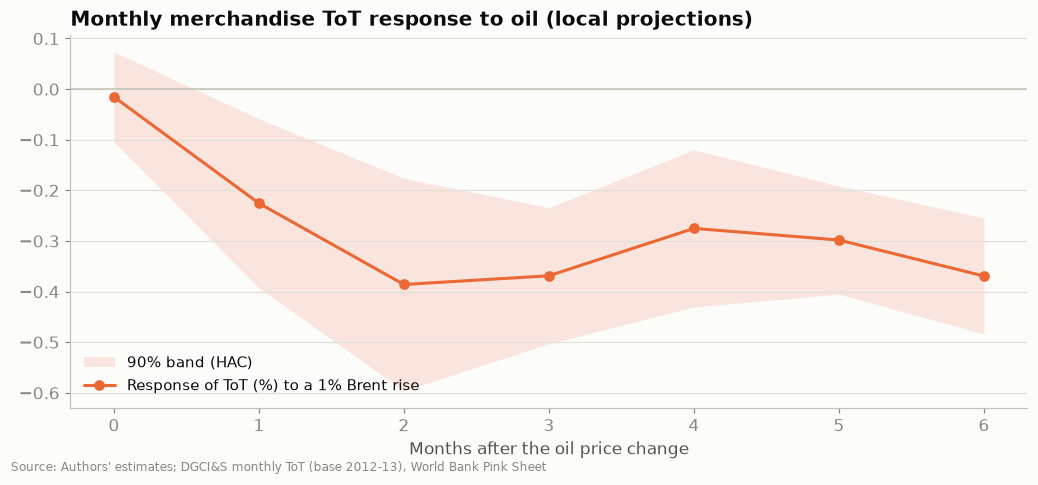

,beta,se,N
h,,,
0,-0.015,0.054,85
1,-0.226,0.101,84
2,-0.386,0.128,83
3,-0.369,0.082,82
4,-0.275,0.094,81
5,-0.298,0.065,80
6,-0.369,0.070,79


In [4]:
mm = m.loc["2019-01":"2026-06"].copy()
mm["l_ntt"] = 100 * np.log(mm.ntt_b12)
mm["dlp"] = 100 * np.log(mm.brent).diff()
lp = econ.local_projection(mm.dropna(subset=["dlp"]), "l_ntt", "dlp", horizons=6, controls_lags=1)
save_table(lp, "t08_local_projections_monthly")
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.fill_between(lp.index, lp.beta - 1.645 * lp.se, lp.beta + 1.645 * lp.se, color=ORANGE, alpha=0.15, lw=0, label="90% band (HAC)")
ax.plot(lp.index, lp.beta, color=ORANGE, marker="o", ms=6, label="Response of ToT (%) to a 1% Brent rise")
ax.axhline(0, color=AXIS, lw=1)
ax.set_xlabel("Months after the oil price change"); ax.set_title("Monthly merchandise ToT response to oil (local projections)")
ax.legend(loc="lower left")
fig.tight_layout()
save(fig, "fig11_local_projections_monthly", "Authors' estimates; DGCI&S monthly ToT (base 2012-13), World Bank Pink Sheet")
plt.show()
lp

**Reading.**
- There is almost no effect in the month of the price change.
- The ToT then falls by about 0.3–0.45% per 1% Brent increase after 1–3 months, and the effect persists.
- The lag reflects how crude is bought: cargoes are priced on earlier benchmarks and recorded at customs on arrival.
- **2026 Hormuz crisis:** India's export unit values (refined fuels) rose almost as fast as import unit values in March–April 2026, so the ToT fell only by June (−13% from February). See notebook 01.